In [22]:
import pandas as pd
import numpy as np
from DATA.stock_invest_function import *
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
def setup_korean_font():
    """운영체제에 맞는 한글 폰트 설정"""
    system = platform.system()

    try:
        if system == "Windows":
            # Windows의 경우
            font_candidates = ['Malgun Gothic', 'Microsoft YaHei', 'SimHei']
        elif system == "Darwin":  # macOS
            font_candidates = ['AppleGothic', 'Apple SD Gothic Neo']
        else:  # Linux
            font_candidates = ['DejaVu Sans', 'Liberation Sans']

        # 사용 가능한 폰트 찾기
        available_fonts = [f.name for f in fm.fontManager.ttflist]

        for font in font_candidates:
            if font in available_fonts:
                plt.rcParams['font.family'] = font
                print(f"한글 폰트 설정 완료: {font}")
                break
        else:
            # 대안: 유니코드를 지원하는 기본 폰트
            plt.rcParams['font.family'] = 'DejaVu Sans'
            print("기본 유니코드 폰트 사용")

        # 마이너스 기호 깨짐 방지
        plt.rcParams['axes.unicode_minus'] = False

    except Exception as e:
        print(f"폰트 설정 오류: {e}")
        # 안전한 기본 설정
        plt.rcParams['font.family'] = 'DejaVu Sans'
        plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 설정 실행
setup_korean_font()

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': get_db_host(),
    'port': '3307',
    'database': 'investar'
}

# 설정값들 (선택사항 - 기본 분석용)
# target_ticker = 'META'
# target_item = 'sale'

# 또는 여러 분석을 한 번에 하고 싶다면:
analysis_list = [
    ('META', 'sale'),
    ('AAPL', 'sale'),
    ('GOOGL', 'netincome'),
    ('TSLA', 'sale')
]

# DB 엔진 생성 함수
def make_engine(db_info: dict):
    return create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}",
        pool_pre_ping=True
    )

# ticker 데이터 조회 함수
def fetch_ticker_data(engine, table_name: str, ticker: str, ticker_col: str = "ticker") -> pd.DataFrame:
    sql = text(f"SELECT * FROM `{table_name}` WHERE `{ticker_col}` = :ticker")
    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params={"ticker": ticker})
    return df

# 성장률 계산 함수
def calculate_growth_rates(df):
    """분기별, 연간 성장률을 계산하는 함수"""
    growth_df = df.copy()
    growth_df = growth_df.sort_values('date').reset_index(drop=True)

    # 분기별 성장률 (QoQ: Quarter over Quarter)
    growth_df['qoq_growth_rate'] = growth_df['value'].pct_change() * 100

    # 연간 성장률 (YoY: Year over Year) - 4분기 전과 비교
    growth_df['yoy_growth_rate'] = growth_df['value'].pct_change(periods=4) * 100

    return growth_df

def get_company_name(ticker):
    """티커를 그대로 반환"""
    return ticker

# ==============================================
# 메인 실행 부분
# ==============================================

print("데이터 로딩 중...")
engine = make_engine(db_info)

# 1. 한 번만 전체 데이터 로드 (시간 절약을 위해)
print("전체 미국 기업 재무정보 로딩 중... (처음 한 번만)")
historical_df_full = fetch_table_data(db_info, 'US_IS_from_FMP')
print(f"전체 Historical 데이터 로드 완료: {len(historical_df_full)} 행")

# 2. 전체 예측 데이터도 한 번만 로드 (모든 티커)
print("전체 예측 데이터 로딩 중... (모든 티커)")
try:
    # 모든 티커의 예측 데이터를 한 번에 로드
    sql = text("SELECT * FROM us_fs_forecast_data")
    with engine.connect() as conn:
        forecast_df_full = pd.read_sql(sql, conn)
    print(f"전체 Forecast 데이터 로드 완료: {len(forecast_df_full)} 행")
except Exception as e:
    print(f"예측 데이터 로드 오류: {e}")
    forecast_df_full = pd.DataFrame()

def analyze_ticker_item(ticker, item, historical_df_full, forecast_df_full):
    """특정 티커와 아이템에 대한 분석을 수행하는 함수"""

    print(f"\n========== {ticker} - {item} 분석 ==========")

    # Historical 데이터에서 해당 티커와 아이템 추출
    extracted_df = historical_df_full[(historical_df_full['ticker'] == ticker) &
                                     (historical_df_full['fs_item'] == item)]
    extracted_resize_df = extracted_df[['date', 'ticker', 'fs_item', 'value']]
    historical_fs_df = extracted_resize_df.rename(columns={'fs_item': 'item'})

    # Forecast 데이터에서 해당 티커와 아이템 추출
    df_filtered = forecast_df_full[(forecast_df_full['ticker'] == ticker) &
                                  (forecast_df_full["target_col"] == item)].copy()

    if len(df_filtered) > 0:
        df_filtered["prediction_date"] = pd.to_datetime(df_filtered["prediction_date"])
        forecast_fs_df = df_filtered[
            df_filtered["prediction_date"] == df_filtered["prediction_date"].max()
        ][['forecast_date', 'ticker', 'target_col', 'forecast_value']]
        forecast_fs_df = forecast_fs_df.rename(columns={'forecast_date': 'date',
                                                       'target_col': 'item',
                                                       'forecast_value': 'value'})
    else:
        forecast_fs_df = pd.DataFrame()

    # 데이터 결합
    df = pd.concat([historical_fs_df, forecast_fs_df], ignore_index=True)

    if len(df) == 0:
        print(f"경고: {ticker} - {item}에 대한 데이터가 없습니다.")
        return None, None

    # 날짜 컬럼을 datetime으로 변환
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    # 성장률 계산
    growth_df = calculate_growth_rates(df)

    print(f"데이터 기간: {df['date'].min().strftime('%Y-%m-%d')} ~ {df['date'].max().strftime('%Y-%m-%d')}")
    print(f"총 데이터 포인트: {len(df)}개")

    return df, growth_df


한글 폰트 설정 완료: Malgun Gothic
데이터 로딩 중...
전체 미국 기업 재무정보 로딩 중... (처음 한 번만)
✅ 'US_IS_from_FMP' 테이블에서 6743738건의 데이터를 가져왔습니다.
전체 Historical 데이터 로드 완료: 6743738 행
전체 예측 데이터 로딩 중... (모든 티커)
전체 Forecast 데이터 로드 완료: 84696 행



========== INMD - sale 분석 ==========
데이터 기간: 2017-03-31 ~ 2028-06-30
총 데이터 포인트: 46개

========== 성장률 분석 ==========
마지막 Historical 데이터: 2025-06-30 - $0.1B

Forecast 데이터 성장률 (2025년 3분기 이후):
2025-09-30: $0.1B (QoQ: +0.2%, YoY: -26.4%)
2025-12-31: $0.1B (QoQ: +9.8%, YoY: +7.5%)
2026-03-31: $0.1B (QoQ: -25.3%, YoY: +0.9%)
2026-06-30: $0.1B (QoQ: +20.0%, YoY: -1.4%)
2026-09-30: $0.1B (QoQ: +0.2%, YoY: -1.4%)
2026-12-31: $0.1B (QoQ: +9.9%, YoY: -1.3%)
2027-03-31: $0.1B (QoQ: -25.6%, YoY: -1.7%)
2027-06-30: $0.1B (QoQ: +20.3%, YoY: -1.4%)
2027-09-30: $0.1B (QoQ: +0.2%, YoY: -1.4%)
2027-12-31: $0.1B (QoQ: +10.1%, YoY: -1.3%)
2028-03-31: $0.1B (QoQ: -25.9%, YoY: -1.7%)
2028-06-30: $0.1B (QoQ: +20.6%, YoY: -1.4%)


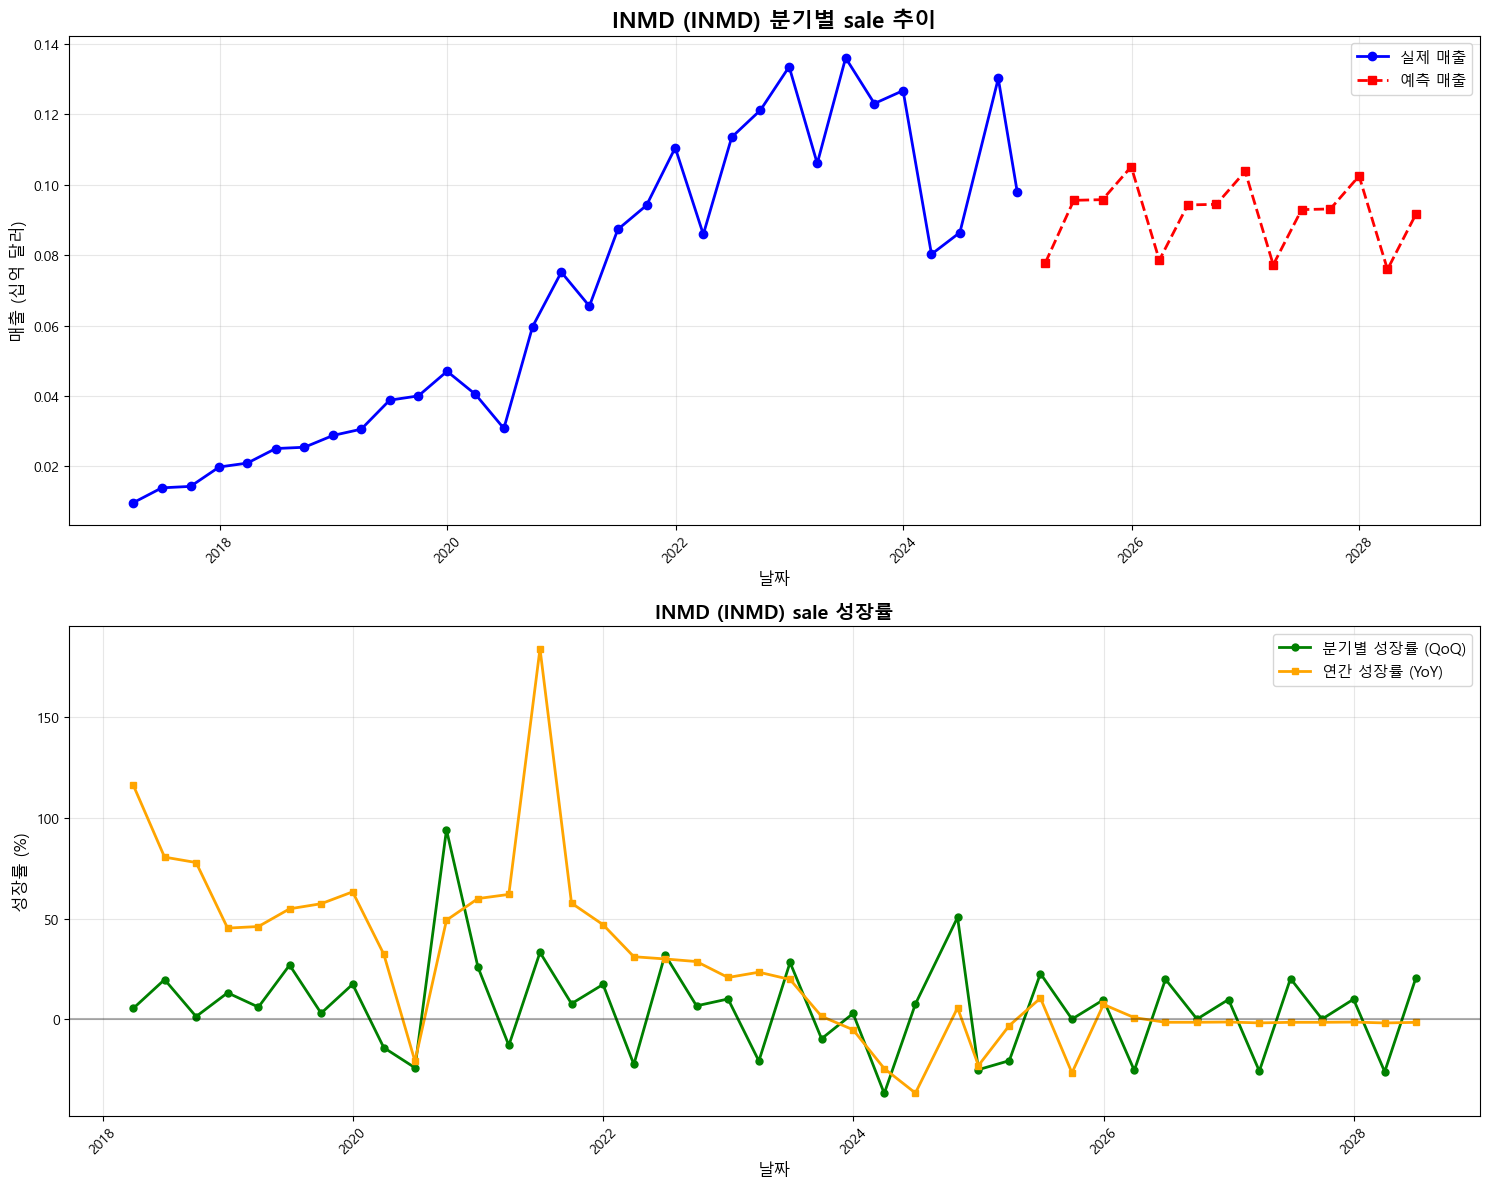


========== sale 통계 ==========
최대 sale: $0.136B (2023-06-30)
최소 sale: $0.010B (2017-03-31)
평균 sale: $0.076B

연도별 sale 합계 (십억 달러):
2017: $0.058B
2018: $0.100B
2019: $0.156B
2020: $0.206B
2021: $0.358B
2022: $0.454B
2023: $0.492B
2024: $0.395B
2025: $0.374B
2026: $0.371B
2027: $0.366B
2028: $0.168B

========== 성장률 통계 ==========
[전체 기간]
평균 분기별 성장률: 7.7%
평균 연간 성장률: 25.3%
최고 분기별 성장률: 94.1%
최고 연간 성장률: 183.8%

[Historical 데이터 (2025년 6월까지)]
평균 분기별 성장률: 10.1%
평균 연간 성장률: 36.4%

[예측 데이터 (2025년 7월 이후)]
평균 예상 분기별 성장률: 1.2%
평균 예상 연간 성장률: -2.6%

========== 다른 분석 예시 ==========
이제 어떤 티커든 빠르게 분석할 수 있습니다 (DB 재조회 없음):
# 애플 분석
df_aapl, growth_aapl = analyze_ticker_item('AAPL', 'sale', historical_df_full, forecast_df_full)
# 구글 순이익 분석
df_googl, growth_googl = analyze_ticker_item('GOOGL', 'netincome', historical_df_full, forecast_df_full)
# 테슬라 분석
df_tsla, growth_tsla = analyze_ticker_item('TSLA', 'sale', historical_df_full, forecast_df_full)


In [64]:
# 기본 분석 실행 (원하는 회사/항목으로 변경)
target_ticker = 'INMD'  # 원하는 티커로 변경
target_item = 'sale'    # 원하는 항목으로 변경

df, growth_df = analyze_ticker_item(target_ticker, target_item, historical_df_full, forecast_df_full)

# 또는 여러 분석을 한 번에 실행하려면:
# for ticker, item in analysis_list:
#     df, growth_df = analyze_ticker_item(ticker, item, historical_df_full, forecast_df_full)
#     if df is not None:
#         print(f"\\n{ticker} - {item} 분석 완료!")
#     print("="*50)

if df is not None:
    # Historical과 Forecast 데이터 구분점 찾기
    historical_data = growth_df[growth_df['date'] <= '2025-06-30']  # 2025년 2분기까지를 historical로 가정
    forecast_data = growth_df[growth_df['date'] > '2025-06-30']     # 2025년 3분기부터를 forecast로 가정

    # 성장률 정보 출력
    print(f"\n========== 성장률 분석 ==========")

    # 마지막 historical 데이터 표시
    if len(historical_data) > 0:
        last_historical = historical_data.iloc[-1]
        last_hist_date = last_historical['date'].strftime('%Y-%m-%d')
        last_hist_value = last_historical['value'] / 1e9
        print(f"마지막 Historical 데이터: {last_hist_date} - ${last_hist_value:.1f}B")

    # Forecast 데이터 성장률 정보 (2025년 3분기부터)
    if len(forecast_data) > 0:
        print(f"\nForecast 데이터 성장률 (2025년 3분기 이후):")
        forecast_growth = forecast_data[['date', 'value', 'qoq_growth_rate', 'yoy_growth_rate']].copy()
        forecast_growth['value_billions'] = forecast_growth['value'] / 1e9

        for idx, row in forecast_growth.iterrows():
            date_str = row['date'].strftime('%Y-%m-%d')
            value_b = row['value_billions']
            qoq = row['qoq_growth_rate']
            yoy = row['yoy_growth_rate']

            qoq_str = f"{qoq:+.1f}%" if pd.notna(qoq) else "N/A"
            yoy_str = f"{yoy:+.1f}%" if pd.notna(yoy) else "N/A"

            print(f"{date_str}: ${value_b:.1f}B (QoQ: {qoq_str}, YoY: {yoy_str})")
    else:
        print("Forecast 데이터가 없습니다.")

    # 시각화
    plt.figure(figsize=(15, 12))

    # 값을 십억 단위로 변환
    df['sales_billions'] = df['value'] / 1e9
    growth_df['sales_billions'] = growth_df['value'] / 1e9

    # 실제 데이터와 예측 데이터 구분
    actual_data = df[df['date'] <= '2024-12-31']
    forecast_data = df[df['date'] > '2024-12-31']

    # 회사명은 티커 사용
    company_name = get_company_name(target_ticker)

    # 첫 번째 서브플롯: 매출 추이
    plt.subplot(2, 1, 1)

    if len(actual_data) > 0:
        plt.plot(actual_data['date'], actual_data['sales_billions'],
                 marker='o', linewidth=2, markersize=6, color='blue', label='실제 매출')

    if len(forecast_data) > 0:
        plt.plot(forecast_data['date'], forecast_data['sales_billions'],
                 marker='s', linewidth=2, markersize=6, color='red', linestyle='--', label='예측 매출')

    plt.title(f'{company_name} ({target_ticker}) 분기별 {target_item} 추이', fontsize=16, fontweight='bold')
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('매출 (십억 달러)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.xticks(rotation=45)

    # 두 번째 서브플롯: 성장률
    plt.subplot(2, 1, 2)

    # 성장률 데이터 (NaN이 아닌 값만)
    growth_data = growth_df.dropna(subset=['qoq_growth_rate', 'yoy_growth_rate'])

    if len(growth_data) > 0:
        plt.plot(growth_data['date'], growth_data['qoq_growth_rate'],
                 marker='o', linewidth=2, markersize=5, color='green', label='분기별 성장률 (QoQ)')
        plt.plot(growth_data['date'], growth_data['yoy_growth_rate'],
                 marker='s', linewidth=2, markersize=5, color='orange', label='연간 성장률 (YoY)')

    plt.title(f'{company_name} ({target_ticker}) {target_item} 성장률', fontsize=14, fontweight='bold')
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('성장률 (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.xticks(rotation=45)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)  # 0% 라인 표시

    plt.tight_layout()
    plt.show()

    # 통계 정보 출력
    print(f"\n========== {target_item} 통계 ==========")
    max_value = df['value'].max()
    min_value = df['value'].min()
    max_date = df[df['value'] == max_value]['date'].iloc[0]
    min_date = df[df['value'] == min_value]['date'].iloc[0]

    print(f"최대 {target_item}: ${max_value/1e9:.3f}B ({max_date.strftime('%Y-%m-%d')})")
    print(f"최소 {target_item}: ${min_value/1e9:.3f}B ({min_date.strftime('%Y-%m-%d')})")
    print(f"평균 {target_item}: ${df['value'].mean()/1e9:.3f}B")

    # 연도별 매출 합계
    df['year'] = df['date'].dt.year
    yearly_sales = df.groupby('year')['value'].sum() / 1e9

    print(f"\n연도별 {target_item} 합계 (십억 달러):")
    for year, sales in yearly_sales.items():
        print(f"{year}: ${sales:.3f}B")

    # 성장률 통계
    if 'qoq_growth_rate' in growth_df.columns:
        # 전체 데이터의 성장률
        valid_qoq = growth_df['qoq_growth_rate'].dropna()
        valid_yoy = growth_df['yoy_growth_rate'].dropna()

        # Historical과 Forecast 데이터 구분 (2025년 6월 30일 기준)
        historical_growth = growth_df[growth_df['date'] <= '2025-06-30']
        forecast_growth = growth_df[growth_df['date'] > '2025-06-30']

        # Historical 성장률
        hist_qoq = historical_growth['qoq_growth_rate'].dropna()
        hist_yoy = historical_growth['yoy_growth_rate'].dropna()

        # Forecast 성장률
        forecast_qoq = forecast_growth['qoq_growth_rate'].dropna()
        forecast_yoy = forecast_growth['yoy_growth_rate'].dropna()

        if len(valid_qoq) > 0:
            print(f"\n========== 성장률 통계 ==========")
            print(f"[전체 기간]")
            print(f"평균 분기별 성장률: {valid_qoq.mean():.1f}%")
            print(f"평균 연간 성장률: {valid_yoy.mean():.1f}%")
            print(f"최고 분기별 성장률: {valid_qoq.max():.1f}%")
            print(f"최고 연간 성장률: {valid_yoy.max():.1f}%")

            if len(hist_qoq) > 0:
                print(f"\n[Historical 데이터 (2025년 6월까지)]")
                print(f"평균 분기별 성장률: {hist_qoq.mean():.1f}%")
                print(f"평균 연간 성장률: {hist_yoy.mean():.1f}%")

            if len(forecast_qoq) > 0:
                print(f"\n[예측 데이터 (2025년 7월 이후)]")
                print(f"평균 예상 분기별 성장률: {forecast_qoq.mean():.1f}%")
                print(f"평균 예상 연간 성장률: {forecast_yoy.mean():.1f}%")

else:
    print("데이터를 찾을 수 없습니다.")

# ==============================================
# 다른 티커나 아이템을 분석하고 싶을 때는 이 부분만 변경하세요
# ==============================================

print(f"\n========== 다른 분석 예시 ==========")
print("이제 어떤 티커든 빠르게 분석할 수 있습니다 (DB 재조회 없음):")
print("# 애플 분석")
print("df_aapl, growth_aapl = analyze_ticker_item('AAPL', 'sale', historical_df_full, forecast_df_full)")
print("# 구글 순이익 분석")
print("df_googl, growth_googl = analyze_ticker_item('GOOGL', 'netincome', historical_df_full, forecast_df_full)")
print("# 테슬라 분석")
print("df_tsla, growth_tsla = analyze_ticker_item('TSLA', 'sale', historical_df_full, forecast_df_full)")

# 실제 다른 회사 분석 예시 (주석 해제하여 사용)
# df_aapl, growth_aapl = analyze_ticker_item('AAPL', 'sale', historical_df_full, forecast_df_full)
# df_googl, growth_googl = analyze_ticker_item('GOOGL', 'netincome', historical_df_full, forecast_df_full)